<a href="https://colab.research.google.com/github/rajibbhowmikcegis/River_Erosion_Prediction/blob/main/river_ep_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

import os
import shutil

mount_point = '/content/drive'

# Only clear if it's a directory and not a *currently active* mount point, but contains files
if os.path.exists(mount_point) and os.path.isdir(mount_point) and not os.path.ismount(mount_point):
    if os.listdir(mount_point):
        print(f"Cleaning non-mounted directory '{mount_point}' before mounting...")
        for filename in os.listdir(mount_point):
            filepath = os.path.join(mount_point, filename)
            try:
                if os.path.isfile(filepath) or os.path.islink(filepath):
                    os.unlink(filepath)
                elif os.path.isdir(filepath):
                    shutil.rmtree(filepath)
            except Exception as e:
                print(f"Error removing {filepath}: {e}. This might cause mount failure.")

drive.mount(mount_point, force_remount=True)

Mounted at /content/drive


In [ ]:
import os

mount_point = '/content/drive' # Define mount_point again for this cell's scope
base_path = os.path.join(mount_point, 'MyDrive')
# Create the first folder
base_folder = os.path.join(base_path, 'GEE_Sentinel1_Jamuna_v4')
os.makedirs(base_folder, exist_ok=True)
print(f"Created folder: {base_folder}")

# Create the first folder
raw_images_folder = os.path.join(base_folder, 'raw_images')
os.makedirs(raw_images_folder, exist_ok=True)
print(f"Created folder: {raw_images_folder}")

# Create the second folder
raw_masks_folder = os.path.join(base_folder, 'raw_masks')
os.makedirs(raw_masks_folder, exist_ok=True)
print(f"Created folder: {raw_masks_folder}")

Created folder: /content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4
Created folder: /content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/raw_images
Created folder: /content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/raw_masks


In [ ]:
import os
import shutil

mount_point = '/content/drive' # Ensure mount_point is defined for this cell
base_path = os.path.join(mount_point, 'MyDrive')

source_folder_name = 'GEE_Sentinel1_Jamuna_v4_raw_images'
source_folder_path = os.path.join(base_path, source_folder_name)
destination_folder_path = os.path.join(base_path, 'GEE_Sentinel1_Jamuna_v4', 'raw_images')

if os.path.exists(source_folder_path) and os.path.isdir(source_folder_path):
    print(f"Moving contents from '{source_folder_path}' to '{destination_folder_path}'...")
    for item_name in os.listdir(source_folder_path):
        source_item_path = os.path.join(source_folder_path, item_name)
        destination_item_path = os.path.join(destination_folder_path, item_name)
        shutil.move(source_item_path, destination_item_path)
    print("Move complete. Deleting empty source folder...")
    os.rmdir(source_folder_path)
    print(f"Removed empty folder: {source_folder_path}")
else:
    print(f"Source folder '{source_folder_path}' does not exist or is not a directory. No files to move.")

Moving contents from '/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4_raw_images' to '/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/raw_images'...
Move complete. Deleting empty source folder...
Removed empty folder: /content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4_raw_images


In [ ]:
import os
import shutil

mount_point = '/content/drive' # Ensure mount_point is defined for this cell
base_path = os.path.join(mount_point, 'MyDrive')

source_folder_name = 'GEE_Sentinel1_Jamuna_v4_raw_masks'
source_folder_path = os.path.join(base_path, source_folder_name)
destination_folder_path = os.path.join(base_path, 'GEE_Sentinel1_Jamuna_v4', 'raw_masks')

if os.path.exists(source_folder_path) and os.path.isdir(source_folder_path):
    print(f"Moving contents from '{source_folder_path}' to '{destination_folder_path}'...")
    for item_name in os.listdir(source_folder_path):
        source_item_path = os.path.join(source_folder_path, item_name)
        destination_item_path = os.path.join(destination_folder_path, item_name)
        shutil.move(source_item_path, destination_item_path)
    print("Move complete. Deleting empty source folder...")
    os.rmdir(source_folder_path)
    print(f"Removed empty folder: {source_folder_path}")
else:
    print(f"Source folder '{source_folder_path}' does not exist or is not a directory. No files to move.")

Moving contents from '/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4_raw_masks' to '/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/raw_masks'...
Move complete. Deleting empty source folder...
Removed empty folder: /content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4_raw_masks


In [ ]:
import os

base_dir = "/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4"

folders = [
    "train_images",
    "train_masks",
    "val_images",
    "val_masks",
    "test_images",
    "test_masks",
    "models",
    "prediction_output"
]

for folder in folders:
    os.makedirs(os.path.join(base_dir, folder), exist_ok=True)

print("Folder structure created successfully.")

Folder structure created successfully.


In [ ]:
import os
import re

raw_image_dir = "/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/raw_images"
raw_mask_dir  = "/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/raw_masks"

image_files = sorted([f for f in os.listdir(raw_image_dir) if f.lower().endswith(".tif")])
mask_files  = sorted([f for f in os.listdir(raw_mask_dir) if f.lower().endswith(".tif")])

print("Number of raw images:", len(image_files))
print("Number of masks     :", len(mask_files))

def image_key(filename):
    # Example:
    # S1_Jamuna_2020_Jan-0000000000-0000000000.tif
    m = re.search(r"S1_Jamuna_(\d{4})_(Jan|Feb|Nov|Dec)(.*)\.tif$", filename)
    if m:
        year = m.group(1)
        month = m.group(2)
        suffix = m.group(3)
        return year, month, suffix
    return None

def mask_key(filename):
    # Example:
    # Jamuna_Erosion_2020_Jan_mask-0000000000-0000000000.tif
    m = re.search(r"Jamuna_Erosion_(\d{4})_(Jan|Feb|Nov|Dec)_mask(.*)\.tif$", filename)
    if m:
        year = m.group(1)
        month = m.group(2)
        suffix = m.group(3)
        return year, month, suffix
    return None

image_keys = {image_key(f): f for f in image_files if image_key(f)}
mask_keys  = {mask_key(f): f for f in mask_files if mask_key(f)}

missing_masks = []
missing_images = []

for key in image_keys:
    if key not in mask_keys:
        missing_masks.append((key, image_keys[key]))

for key in mask_keys:
    if key not in image_keys:
        missing_images.append((key, mask_keys[key]))

print("\nMatched pairs:", len(set(image_keys.keys()) & set(mask_keys.keys())))
print("Missing masks :", len(missing_masks))
print("Missing images:", len(missing_images))

if missing_masks:
    print("\nRaw images without matching mask:")
    for key, file in missing_masks:
        print(key, file)

if missing_images:
    print("\nMasks without matching raw image:")
    for key, file in missing_images:
        print(key, file)

if len(missing_masks) == 0 and len(missing_images) == 0:
    print("\n✅ Perfect: raw image count and mask image count are matched.")
else:
    print("\n⚠️ Problem: some image/mask files are missing.")

Number of raw images: 170
Number of masks     : 170

Matched pairs: 170
Missing masks : 0
Missing images: 0

✅ Perfect: raw image count and mask image count are matched.


In [ ]:
import os
import re
import random
import rasterio
from rasterio.windows import Window
from tqdm import tqdm
import numpy as np
import time # Import time for sleep function


# ==============================
# Base folder
# ==============================

base_dir = "/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4"

# If your exported files are still in separate GEE folders, use these:
raw_image_dir = "/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/raw_images"
raw_mask_dir  = "/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/raw_masks"

# Output folders for U-Net
train_image_dir = os.path.join(base_dir, "train_images")
train_mask_dir  = os.path.join(base_dir, "train_masks")

val_image_dir = os.path.join(base_dir, "val_images")
val_mask_dir  = os.path.join(base_dir, "val_masks")

test_image_dir = os.path.join(base_dir, "test_images")
test_mask_dir  = os.path.join(base_dir, "test_masks")

folders = [
    train_image_dir, train_mask_dir,
    val_image_dir, val_mask_dir,
    test_image_dir, test_mask_dir
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Output folders created.")

def image_key(filename):
    """
    Example:
    S1_Jamuna_2020_Jan-0000000000-0000000000.tif
    """
    m = re.search(r"S1_Jamuna_(\d{4})_(Jan|Feb|Nov|Dec)(.*)\.tif$", filename)
    if m:
        year = m.group(1)
        month = m.group(2)
        suffix = m.group(3)
        return year, month, suffix
    return None


def mask_key(filename):
    """
    Example:
    Jamuna_Erosion_2020_Jan_mask-0000000000-0000000000.tif
    """
    m = re.search(r"Jamuna_Erosion_(\d{4})_(Jan|Feb|Nov|Dec)_mask(.*)\.tif$", filename)
    if m:
        year = m.group(1)
        month = m.group(2)
        suffix = m.group(3)
        return year, month, suffix
    return None


image_files = sorted([f for f in os.listdir(raw_image_dir) if f.lower().endswith(".tif")])
mask_files  = sorted([f for f in os.listdir(raw_mask_dir) if f.lower().endswith(".tif")])

image_dict = {}
mask_dict = {}

for f in image_files:
    key = image_key(f)
    if key:
        image_dict[key] = f

for f in mask_files:
    key = mask_key(f)
    if key:
        mask_dict[key] = f

common_keys = sorted(set(image_dict.keys()) & set(mask_dict.keys()))

print("Raw image files:", len(image_files))
print("Mask files     :", len(mask_files))
print("Matched pairs  :", len(common_keys))

missing_masks = sorted(set(image_dict.keys()) - set(mask_dict.keys()))
missing_images = sorted(set(mask_dict.keys()) - set(image_dict.keys()))

print("Missing masks :", len(missing_masks))
print("Missing images:", len(missing_images))

if missing_masks:
    print("Raw images without masks:")
    for k in missing_masks[:20]:
        print(k, image_dict[k])

if missing_images:
    print("Masks without raw images:")
    for k in missing_images[:20]:
        print(k, mask_dict[k])



def save_tile(src, window, out_path, dtype=None):
    profile = src.profile.copy()
    transform = src.window_transform(window)

    profile.update({
        "height": window.height,
        "width": window.width,
        "transform": transform,
        "compress": "lzw"
    })

    data = src.read(window=window)

    if dtype is not None:
        data = data.astype(dtype)
        profile.update(dtype=dtype)

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(data)

        # ==============================
# Tile settings
# ==============================

tile_size = 512
stride = 512

train_ratio = 0.70
val_ratio   = 0.15
test_ratio  = 0.15

random.seed(42)

tile_count = 0
train_count = 0
val_count = 0
test_count = 0
skipped_count = 0

MAX_RETRIES = 5
RETRY_DELAY_SEC = 2

for key in common_keys:

    year, month, suffix = key

    image_file = image_dict[key]
    mask_file  = mask_dict[key]

    image_path = os.path.join(raw_image_dir, image_file)
    mask_path  = os.path.join(raw_mask_dir, mask_file)

    print(f"\nProcessing: {year} {month} {suffix}")
    print("Image:", image_file)
    print("Mask :", mask_file)

    for retry_attempt in range(MAX_RETRIES):
        try:
            with rasterio.open(image_path) as img_src, rasterio.open(mask_path) as mask_src:

                # Check image and mask alignment
                if img_src.width != mask_src.width or img_src.height != mask_src.height:
                    print("Size mismatch. Skipping:", image_file)
                    print("Image size:", img_src.width, img_src.height)
                    print("Mask size :", mask_src.width, mask_src.height)
                    skipped_count += 1
                    break # Break retry loop, go to next key

                if img_src.crs != mask_src.crs:
                    print("CRS mismatch. Skipping:", image_file)
                    skipped_count += 1
                    break # Break retry loop, go to next key

                if img_src.transform != mask_src.transform:
                    print("Transform mismatch. Skipping:", image_file)
                    skipped_count += 1
                    break # Break retry loop, go to next key

                width = img_src.width
                height = img_src.height

                for row in range(0, height - tile_size + 1, stride):
                    for col in range(0, width - tile_size + 1, stride):

                        window = Window(col, row, tile_size, tile_size)

                        image_tile = img_src.read(window=window)
                        mask_tile = mask_src.read(1, window=window)

                        # Skip invalid raw image tile
                        # Because raw image unmask value may be -9999
                        if np.all(image_tile == -9999):
                            skipped_count += 1
                            continue

                        # Optional: skip tiles with no erosion at all
                        # For erosion model, keeping some no-erosion tiles is useful.
                        # But too many empty masks reduce learning quality.
                        # Here we keep all non-empty image tiles.
                        # Uncomment below to skip completely no-erosion mask tiles:
                        #
                        # if np.sum(mask_tile == 1) == 0:
                        #     skipped_count += 1
                        #     continue

                        r = random.random()

                        if r < train_ratio:
                            out_img_dir = train_image_dir
                            out_msk_dir = train_mask_dir
                            train_count += 1
                        elif r < train_ratio + val_ratio:
                            out_img_dir = val_image_dir
                            out_msk_dir = val_mask_dir
                            val_count += 1
                        else:
                            out_img_dir = test_image_dir
                            out_msk_dir = test_mask_dir
                            test_count += 1

                        clean_suffix = suffix.replace("-", "_")
                        tile_name = f"S1_Jamuna_{year}_{month}{clean_suffix}_tile_{tile_count:06d}.tif"

                        image_tile_path = os.path.join(out_img_dir, tile_name)
                        mask_tile_path  = os.path.join(out_msk_dir, tile_name)

                        save_tile(img_src, window, image_tile_path, dtype="float32")
                        save_tile(mask_src, window, mask_tile_path, dtype="uint8")

                        tile_count += 1
            break # Break retry loop if successful
        except rasterio.errors.RasterioIOError as e:
            print(f"Error opening files for {key} (Attempt {retry_attempt + 1}/{MAX_RETRIES}): {e}")
            if retry_attempt < MAX_RETRIES - 1:
                time.sleep(RETRY_DELAY_SEC)
            else:
                print(f"Failed to open files for {key} after {MAX_RETRIES} attempts. Skipping this pair.")
                skipped_count += 1


print("\nTiling completed.")
print("Total tiles  :", tile_count)
print("Train tiles  :", train_count)
print("Val tiles    :", val_count)
print("Test tiles   :", test_count)
print("Skipped tiles:", skipped_count)

Output folders created.
Raw image files: 170
Mask files     : 170
Matched pairs  : 170
Missing masks : 0
Missing images: 0

Processing: 2016 Dec -0000000000-0000000000
Image: S1_Jamuna_2016_Dec-0000000000-0000000000.tif
Mask : Jamuna_Erosion_2016_Dec_mask-0000000000-0000000000.tif

Processing: 2016 Dec -0000005120-0000000000
Image: S1_Jamuna_2016_Dec-0000005120-0000000000.tif
Mask : Jamuna_Erosion_2016_Dec_mask-0000005120-0000000000.tif

Processing: 2016 Dec -0000010240-0000000000
Image: S1_Jamuna_2016_Dec-0000010240-0000000000.tif
Mask : Jamuna_Erosion_2016_Dec_mask-0000010240-0000000000.tif

Processing: 2016 Dec -0000015360-0000000000
Image: S1_Jamuna_2016_Dec-0000015360-0000000000.tif
Mask : Jamuna_Erosion_2016_Dec_mask-0000015360-0000000000.tif

Processing: 2016 Dec -0000020480-0000000000
Image: S1_Jamuna_2016_Dec-0000020480-0000000000.tif
Mask : Jamuna_Erosion_2016_Dec_mask-0000020480-0000000000.tif

Processing: 2016 Nov -0000000000-0000000000
Image: S1_Jamuna_2016_Nov-0000000000-


Processing: 2023 Dec -0000020480-0000000000
Image: S1_Jamuna_2023_Dec-0000020480-0000000000.tif
Mask : Jamuna_Erosion_2023_Dec_mask-0000020480-0000000000.tif

Processing: 2023 Feb -0000000000-0000000000
Image: S1_Jamuna_2023_Feb-0000000000-0000000000.tif
Mask : Jamuna_Erosion_2023_Feb_mask-0000000000-0000000000.tif

Processing: 2023 Feb -0000005120-0000000000
Image: S1_Jamuna_2023_Feb-0000005120-0000000000.tif
Mask : Jamuna_Erosion_2023_Feb_mask-0000005120-0000000000.tif

Processing: 2023 Feb -0000010240-0000000000
Image: S1_Jamuna_2023_Feb-0000010240-0000000000.tif
Mask : Jamuna_Erosion_2023_Feb_mask-0000010240-0000000000.tif

Processing: 2023 Feb -0000015360-0000000000
Image: S1_Jamuna_2023_Feb-0000015360-0000000000.tif
Mask : Jamuna_Erosion_2023_Feb_mask-0000015360-0000000000.tif

Processing: 2023 Feb -0000020480-0000000000
Image: S1_Jamuna_2023_Feb-0000020480-0000000000.tif
Mask : Jamuna_Erosion_2023_Feb_mask-0000020480-0000000000.tif

Processing: 2023 Jan -0000000000-0000000000
I

In [ ]:
def count_tif(folder):
    return len([f for f in os.listdir(folder) if f.lower().endswith(".tif")])

print("train_images:", count_tif(train_image_dir))
print("train_masks :", count_tif(train_mask_dir))

print("val_images  :", count_tif(val_image_dir))
print("val_masks   :", count_tif(val_mask_dir))

print("test_images :", count_tif(test_image_dir))
print("test_masks  :", count_tif(test_mask_dir))







train_images: 5744
train_masks : 5744
val_images  : 1237
val_masks   : 1237
test_images : 1179
test_masks  : 1179


In [ ]:
for img_folder, mask_folder, name in [
    (train_image_dir, train_mask_dir, "train"),
    (val_image_dir, val_mask_dir, "val"),
    (test_image_dir, test_mask_dir, "test")
]:
    img_files = sorted([f for f in os.listdir(img_folder) if f.lower().endswith(".tif")])
    msk_files = sorted([f for f in os.listdir(mask_folder) if f.lower().endswith(".tif")])

    img_set = set(img_files)
    msk_set = set(msk_files)

    print("\n", name.upper())
    print("Images:", len(img_files))
    print("Masks :", len(msk_files))
    print("Matched:", len(img_set & msk_set))
    print("Missing masks :", len(img_set - msk_set))
    print("Missing images:", len(msk_set - img_set))

    if len(img_set - msk_set) == 0 and len(msk_set - img_set) == 0:
        print("OK:", name, "image-mask pairs matched.")
    else:
        print("Problem found in:", name)


 TRAIN
Images: 5744
Masks : 5744
Matched: 5744
Missing masks : 0
Missing images: 0
OK: train image-mask pairs matched.

 VAL
Images: 1237
Masks : 1237
Matched: 1237
Missing masks : 0
Missing images: 0
OK: val image-mask pairs matched.

 TEST
Images: 1179
Masks : 1179
Matched: 1179
Missing masks : 0
Missing images: 0
OK: test image-mask pairs matched.


In [ ]:
from google.colab import drive

import os
import shutil

mount_point = '/content/drive'

# Only clear if it's a directory and not a *currently active* mount point, but contains files
if os.path.exists(mount_point) and os.path.isdir(mount_point) and not os.path.ismount(mount_point):
    if os.listdir(mount_point):
        print(f"Cleaning non-mounted directory '{mount_point}' before mounting...")
        for filename in os.listdir(mount_point):
            filepath = os.path.join(mount_point, filename)
            try:
                if os.path.isfile(filepath) or os.path.islink(filepath):
                    os.unlink(filepath)
                elif os.path.isdir(filepath):
                    shutil.rmtree(filepath)
            except Exception as e:
                print(f"Error removing {filepath}: {e}. This might cause mount failure.")

drive.mount(mount_point, force_remount=True)

Cleaning non-mounted directory '/content/drive' before mounting...
Mounted at /content/drive


In [ ]:
!pip install rasterio -q

In [ ]:
import os
import numpy as np
import rasterio
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


base_dir = "/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4"

train_image_dir = os.path.join(base_dir, "train_images")
train_mask_dir  = os.path.join(base_dir, "train_masks")

val_image_dir = os.path.join(base_dir, "val_images")
val_mask_dir  = os.path.join(base_dir, "val_masks")

test_image_dir = os.path.join(base_dir, "test_images")
test_mask_dir  = os.path.join(base_dir, "test_masks")

model_dir = os.path.join(base_dir, "models")
prediction_dir = os.path.join(base_dir, "prediction_output")

os.makedirs(model_dir, exist_ok=True)
os.makedirs(prediction_dir, exist_ok=True)


train_images = sorted([f for f in os.listdir(train_image_dir) if f.endswith(".tif")])
train_masks  = sorted([f for f in os.listdir(train_mask_dir) if f.endswith(".tif")])

val_images = sorted([f for f in os.listdir(val_image_dir) if f.endswith(".tif")])
val_masks  = sorted([f for f in os.listdir(val_mask_dir) if f.endswith(".tif")])

test_images = sorted([f for f in os.listdir(test_image_dir) if f.endswith(".tif")])
test_masks  = sorted([f for f in os.listdir(test_mask_dir) if f.endswith(".tif")])

print("Train images:", len(train_images))
print("Train masks :", len(train_masks))

print("Val images:", len(val_images))
print("Val masks :", len(val_masks))

print("Test images:", len(test_images))
print("Test masks :", len(test_masks))

assert train_images == train_masks, "Train image and mask names do not match"
assert val_images == val_masks, "Validation image and mask names do not match"
assert test_images == test_masks, "Test image and mask names do not match"

print("All image-mask names matched.")

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train images: 5744
Train masks : 5744
Val images: 1237
Val masks : 1237
Test images: 1179
Test masks : 1179
All image-mask names matched.


In [ ]:
sample_path = os.path.join(train_image_dir, train_images[0])

with rasterio.open(sample_path) as src:
    sample = src.read()
    print("Sample shape:", sample.shape)
    print("Bands:", src.count)
    print("Width:", src.width)
    print("Height:", src.height)

Sample shape: (3, 512, 512)
Bands: 3
Width: 512
Height: 512


In [ ]:
IMG_SIZE = 512
N_CHANNELS = 3
BATCH_SIZE = 4


def read_image_mask(image_path, mask_path):
    image_path = image_path.decode("utf-8")
    mask_path = mask_path.decode("utf-8")

    # Read image
    with rasterio.open(image_path) as src:
        image = src.read().astype(np.float32)  # shape: bands, height, width

    # Convert to TensorFlow format: height, width, bands
    image = np.transpose(image, (1, 2, 0))

    # Replace no-data value
    image[image == -9999] = 0

    # Normalize Sentinel-1 dB values
    # VV/VH normally around -30 to 5 dB
    image = np.clip(image, -30, 5)
    image = (image + 30) / 35.0

    # Read mask
    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.float32)

    # Ensure 0/1 mask
    mask = (mask > 0).astype(np.float32)

    # Add channel dimension: height, width, 1
    mask = np.expand_dims(mask, axis=-1)

    return image, mask


def tf_read_image_mask(image_path, mask_path):
    image, mask = tf.numpy_function(
        read_image_mask,
        [image_path, mask_path],
        [tf.float32, tf.float32]
    )

    image.set_shape([IMG_SIZE, IMG_SIZE, N_CHANNELS])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])

    return image, mask


def create_dataset(image_dir, mask_dir, file_list, batch_size=4, shuffle=True):
    image_paths = [os.path.join(image_dir, f) for f in file_list]
    mask_paths  = [os.path.join(mask_dir, f) for f in file_list]

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(file_list), seed=42)

    dataset = dataset.map(tf_read_image_mask, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset



train_ds = create_dataset(train_image_dir, train_mask_dir, train_images, BATCH_SIZE, shuffle=True)
val_ds   = create_dataset(val_image_dir, val_mask_dir, val_images, BATCH_SIZE, shuffle=False)
test_ds  = create_dataset(test_image_dir, test_mask_dir, test_images, BATCH_SIZE, shuffle=False)

print("Dataset ready.")

Dataset ready.


In [ ]:
#Build U net Model

def conv_block(inputs, filters):
    x = layers.Conv2D(filters, 3, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    return x


def encoder_block(inputs, filters):
    x = conv_block(inputs, filters)
    p = layers.MaxPooling2D((2, 2))(x)
    return x, p


def decoder_block(inputs, skip, filters):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(inputs)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x


def build_unet(input_shape=(512, 512, 3)):
    inputs = layers.Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 32)
    s2, p2 = encoder_block(p1, 64)
    s3, p3 = encoder_block(p2, 128)
    s4, p4 = encoder_block(p3, 256)

    # Bridge
    b1 = conv_block(p4, 512)

    # Decoder
    d1 = decoder_block(b1, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)

    # Output
    outputs = layers.Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    model = models.Model(inputs, outputs, name="U-Net_Jamuna_Erosion")
    return model



model = build_unet(input_shape=(IMG_SIZE, IMG_SIZE, N_CHANNELS))
model.summary()



#Loss Function and Metrics
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)



model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[
        dice_coef,
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)


#Train U Net Model
best_model_path = os.path.join(model_dir, "unet_jamuna_erosion_best.keras")
final_model_path = os.path.join(model_dir, "unet_jamuna_erosion_final.keras")

callbacks = [
    ModelCheckpoint(
        best_model_path,
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]



EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

model.save(final_model_path)

print("Training completed.")
print("Best model:", best_model_path)
print("Final model:", final_model_path)

Model: "U-Net_Jamuna_Erosion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 512, 512,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 512, 512,  │      9,248 │ activation_18[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 256, 256,  │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 256, 256,  │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 256, 256,  │     36,928 │ activation_20[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 128, 128,  │          0 │ activation_21[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_23[0][0] 

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

Epoch 1/30
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9732 - dice_coef: nan - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 1: val_dice_coef improved from None to nan, saving model to /content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/models/unet_jamuna_erosion_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/models/unet_jamuna_erosion_best.keras
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 3648s 3s/step - accuracy: 0.9735 - dice_coef: nan - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9737 - val_dice_coef: nan - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/30
1435/1436 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9727 - dice_coef: nan - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 2: val_dice_coef did not improve from nan
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 3388s 2s/step - accuracy: 0.9735 - dice_coef: nan - loss: nan - precision: 0.00

In [ ]:
import numpy as np

for images, masks in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Mask shape :", masks.shape)

    print("Image min:", tf.reduce_min(images).numpy())
    print("Image max:", tf.reduce_max(images).numpy())
    print("Mask min :", tf.reduce_min(masks).numpy())
    print("Mask max :", tf.reduce_max(masks).numpy())

    print("Image NaN:", np.isnan(images.numpy()).sum())
    print("Mask NaN :", np.isnan(masks.numpy()).sum())

    print("Mask unique:", np.unique(masks.numpy()))

Image shape: (4, 512, 512, 3)
Mask shape : (4, 512, 512, 1)
Image min: nan
Image max: nan
Mask min : 0.0
Mask max : 1.0
Image NaN: 1736727
Mask NaN : 0
Mask unique: [0. 1.]


In [ ]:
#Step 11: Evaluate on test data
import tensorflow as tf
import os
import numpy as np
import rasterio

# Redefine necessary paths and variables to ensure they are available in this cell's scope
base_dir = "/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4"
model_dir = os.path.join(base_dir, "models")
best_model_path = os.path.join(model_dir, "unet_jamuna_erosion_best.keras")

# Dataset parameters (from vFAdGpDPYwRF)
IMG_SIZE = 512
N_CHANNELS = 3
BATCH_SIZE = 4

# Directory and file list definitions (from hUr1DZCSWLu2)
train_image_dir = os.path.join(base_dir, "train_images")
train_mask_dir  = os.path.join(base_dir, "train_masks")
val_image_dir = os.path.join(base_dir, "val_images")
val_mask_dir  = os.path.join(base_dir, "val_masks")
test_image_dir = os.path.join(base_dir, "test_images")
test_mask_dir  = os.path.join(base_dir, "test_masks")

train_images = sorted([f for f in os.listdir(train_image_dir) if f.endswith(".tif")])
train_masks  = sorted([f for f in os.listdir(train_mask_dir) if f.endswith(".tif")])
val_images = sorted([f for f in os.listdir(val_image_dir) if f.endswith(".tif")])
val_masks  = sorted([f for f in os.listdir(val_mask_dir) if f.endswith(".tif")])
test_images = sorted([f for f in os.listdir(test_image_dir) if f.endswith(".tif")])
test_masks  = sorted([f for f in os.listdir(test_mask_dir) if f.endswith(".tif")])


# Loss Function and Metrics definitions (copied from cell BsEFKrftaFnD)
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)


# Data reading and dataset creation functions (from vFAdGpDPYwRF)
def read_image_mask(image_path, mask_path):
    image_path = image_path.decode("utf-8")
    mask_path = mask_path.decode("utf-8")

    with rasterio.open(image_path) as src:
        image = src.read().astype(np.float32)
    image = np.transpose(image, (1, 2, 0))
    image[image == -9999] = 0
    image = np.clip(image, -30, 5)
    image = (image + 30) / 35.0

    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.float32)
    mask = (mask > 0).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)

    return image, mask


def tf_read_image_mask(image_path, mask_path):
    image, mask = tf.numpy_function(
        read_image_mask,
        [image_path, mask_path],
        [tf.float32, tf.float32]
    )
    image.set_shape([IMG_SIZE, IMG_SIZE, N_CHANNELS])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return image, mask


def create_dataset(image_dir, mask_dir, file_list, batch_size=4, shuffle=True):
    image_paths = [os.path.join(image_dir, f) for f in file_list]
    mask_paths  = [os.path.join(mask_dir, f) for f in file_list]

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(file_list), seed=42)
    dataset = dataset.map(tf_read_image_mask, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


# Instantiate datasets
train_ds = create_dataset(train_image_dir, train_mask_dir, train_images, BATCH_SIZE, shuffle=True)
val_ds   = create_dataset(val_image_dir, val_mask_dir, val_images, BATCH_SIZE, shuffle=False)
test_ds  = create_dataset(test_image_dir, test_mask_dir, test_images, BATCH_SIZE, shuffle=False)

best_model = tf.keras.models.load_model(
    best_model_path,
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "dice_coef": dice_coef,
        "dice_loss": dice_loss
    }
)

test_result = best_model.evaluate(test_ds)

print("Test result:")
for name, value in zip(best_model.metrics_names, test_result):
    print(name, ":", value)

295/295 ━━━━━━━━━━━━━━━━━━━━ 135s 363ms/step - accuracy: 0.9735 - dice_coef: nan - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00
Test result:
loss : nan
compile_metrics : nan


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


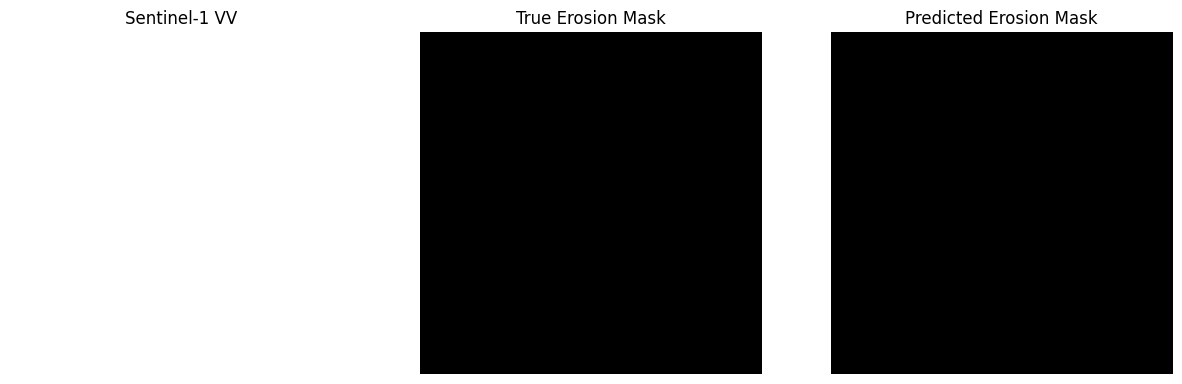

In [ ]:
import matplotlib.pyplot as plt

test_file = test_images[0]

image_path = os.path.join(test_image_dir, test_file)
mask_path  = os.path.join(test_mask_dir, test_file)

image, mask = read_image_mask(image_path.encode(), mask_path.encode())

pred = best_model.predict(np.expand_dims(image, axis=0))[0]
pred_mask = (pred > 0.5).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Sentinel-1 VV")
plt.imshow(image[:, :, 0], cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("True Erosion Mask")
plt.imshow(mask[:, :, 0], cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Predicted Erosion Mask")
plt.imshow(pred_mask[:, :, 0], cmap="gray")
plt.axis("off")

plt.show()

In [ ]:
def save_prediction_geotiff(input_image_path, prediction_mask, output_path):
    with rasterio.open(input_image_path) as src:
        profile = src.profile.copy()

    profile.update({
        "count": 1,
        "dtype": "uint8",
        "compress": "lzw"
    })

    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(prediction_mask[:, :, 0].astype(np.uint8), 1)

# Define output_pred_path before calling the function
base_dir = "/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4"
prediction_dir = os.path.join(base_dir, "prediction_output")
output_pred_path = os.path.join(prediction_dir, "pred_" + test_file)

save_prediction_geotiff(
    image_path,
    pred_mask,
    output_pred_path
)

print("Prediction saved:", output_pred_path)

Prediction saved: /content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/prediction_output/pred_S1_Jamuna_2016_Dec_0000000000_0000000000_tile_000006.tif


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install rasterio -q

In [ ]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window
import tensorflow as tf
from tqdm import tqdm

base_dir = "/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4"

raw_image_dir = "/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/raw_images"
prediction_dir = os.path.join(base_dir, "prediction_output")
os.makedirs(prediction_dir, exist_ok=True)

model_path = os.path.join(base_dir, "models", "unet_jamuna_erosion_best.keras")

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

model = tf.keras.models.load_model(
    model_path,
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "dice_coef": dice_coef,
        "dice_loss": dice_loss
    }
)

print("Model loaded successfully.")

def normalize_sentinel1(image):
    image = image.astype(np.float32)

    # GEE no-data value
    image[image == -9999] = 0

    # Sentinel-1 dB range normalization
    image = np.clip(image, -30, 5)
    image = (image + 30) / 35.0

    return image


def predict_geotiff_part(input_tif, output_tif, model, tile_size=512, threshold=0.5):

    with rasterio.open(input_tif) as src:

        profile = src.profile.copy()
        width = src.width
        height = src.height
        bands = src.count

        print("\nInput:", os.path.basename(input_tif))
        print("Width :", width)
        print("Height:", height)
        print("Bands :", bands)

        if bands != 3:
            raise ValueError("Input image must have 3 bands: VV, VH, VV_minus_VH")

        prediction_full = np.zeros((height, width), dtype=np.uint8)

        for row in tqdm(range(0, height - tile_size + 1, tile_size)):
            for col in range(0, width - tile_size + 1, tile_size):

                window = Window(col, row, tile_size, tile_size)

                image_tile = src.read(window=window)

                # Skip fully empty tile
                if np.all(image_tile == -9999):
                    continue

                image_tile = normalize_sentinel1(image_tile)

                # Convert: bands, height, width → height, width, bands
                image_tile = np.transpose(image_tile, (1, 2, 0))

                # Add batch dimension
                image_tile = np.expand_dims(image_tile, axis=0)

                pred = model.predict(image_tile, verbose=0)[0, :, :, 0]

                pred_mask = (pred >= threshold).astype(np.uint8)

                prediction_full[
                    row:row + tile_size,
                    col:col + tile_size
                ] = pred_mask

        profile.update({
            "count": 1,
            "dtype": "uint8",
            "compress": "lzw",
            "nodata": 0
        })

        with rasterio.open(output_tif, "w", **profile) as dst:
            dst.write(prediction_full, 1)

    print("Saved:", output_tif)


year = "2024"
month = "Dec"

input_files = sorted([
    f for f in os.listdir(raw_image_dir)
    if f.startswith(f"S1_Jamuna_{year}_{month}") and f.lower().endswith(".tif")
])

print("Input files found:", len(input_files))

for f in input_files:
    input_path = os.path.join(raw_image_dir, f)

    output_name = f.replace(
        f"S1_Jamuna_{year}_{month}",
        f"Predicted_Erosion_{year}_{month}"
    )

    output_path = os.path.join(prediction_dir, output_name)

    predict_geotiff_part(
        input_tif=input_path,
        output_tif=output_path,
        model=model,
        tile_size=512,
        threshold=0.5
    )

Model loaded successfully.
Input files found: 5

Input: S1_Jamuna_2024_Dec-0000000000-0000000000.tif
Width : 3060
Height: 5120
Bands : 3


100%|██████████| 10/10 [02:14<00:00, 13.48s/it]


Saved: /content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/prediction_output/Predicted_Erosion_2024_Dec-0000000000-0000000000.tif

Input: S1_Jamuna_2024_Dec-0000005120-0000000000.tif
Width : 3060
Height: 5120
Bands : 3


100%|██████████| 10/10 [02:22<00:00, 14.22s/it]


Saved: /content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/prediction_output/Predicted_Erosion_2024_Dec-0000005120-0000000000.tif

Input: S1_Jamuna_2024_Dec-0000010240-0000000000.tif
Width : 3060
Height: 5120
Bands : 3


...

Saved: /content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/prediction_output/Predicted_Erosion_2024_Dec-0000010240-0000000000.tif

Input: S1_Jamuna_2024_Dec-0000015360-0000000000.tif
Width : 3060
Height: 5120
Bands : 3


100%|██████████| 10/10 [02:05<00:00, 12.58s/it]


Saved: /content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/prediction_output/Predicted_Erosion_2024_Dec-0000015360-0000000000.tif

Input: S1_Jamuna_2024_Dec-0000020480-0000000000.tif
Width : 3060
Height: 4379
Bands : 3


100%|██████████| 8/8 [01:42<00:00, 12.86s/it]

Saved: /content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/prediction_output/Predicted_Erosion_2024_Dec-0000020480-0000000000.tif


In [ ]:
#create 2030 erosion risk map from historical masks

import os
import re
import numpy as np
import rasterio
from tqdm import tqdm

base_dir = "/content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4"

raw_mask_dir = os.path.join(base_dir, "raw_masks")
prediction_dir = os.path.join(base_dir, "prediction_output")

os.makedirs(prediction_dir, exist_ok=True)

target_year = 2030

# Helper function to extract metadata including spatial identifier
def get_mask_metadata(filename):
    # Example: Jamuna_Erosion_2020_Jan_mask-0000000000-0000000000.tif
    m = re.search(r"Jamuna_Erosion_(\d{4})_(Jan|Feb|Nov|Dec)_mask(.*)\.tif$", filename)
    if m:
        year = int(m.group(1))
        month = m.group(2)
        suffix = m.group(3) # This is the spatial identifier
        return year, month, suffix
    return None, None, None

mask_files = sorted([
    f for f in os.listdir(raw_mask_dir)
    if f.lower().endswith(".tif")
])

# Group masks by their unique spatial identifier (suffix)
# Each entry in `grouped_masks_by_suffix` will correspond to a unique spatial tile.
grouped_masks_by_suffix = {} # Key: suffix, Value: list of (year, month, filename)

print("Grouping raw masks by spatial extent...")
for f in mask_files:
    year, month, suffix = get_mask_metadata(f)
    if year is not None and month == "Dec": # Only consider December masks as requested
        if suffix not in grouped_masks_by_suffix:
            grouped_masks_by_suffix[suffix] = []
        grouped_masks_by_suffix[suffix].append((year, month, f))

# Sort the lists within each group by year
for suffix in grouped_masks_by_suffix:
    grouped_masks_by_suffix[suffix].sort()

print(f"Found {len(grouped_masks_by_suffix)} unique spatial extents with December masks.")

all_generated_risk_maps_paths = []

for suffix, masks_for_this_suffix in grouped_masks_by_suffix.items():
    print(f"\nProcessing spatial extent: {suffix}")

    mask_stack_for_suffix = []
    years_for_suffix = []
    reference_profile_for_suffix = None
    reference_shape_for_suffix = None

    for year, month, filename in masks_for_this_suffix:
        mask_path = os.path.join(raw_mask_dir, filename)

        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.uint8)

            # Convert to 0/1 binary mask
            mask = (mask > 0).astype(np.uint8)

            if reference_profile_for_suffix is None:
                reference_profile_for_suffix = src.profile.copy()
                reference_shape_for_suffix = mask.shape
            else:
                if mask.shape != reference_shape_for_suffix:
                    # This should ideally not happen if suffixes correctly identify unique spatial extents
                    print(f"WARNING: Mask size mismatch within spatial extent {suffix}: {filename}. Expected {reference_shape_for_suffix}, got {mask.shape}. Skipping this mask.")
                    continue

            mask_stack_for_suffix.append(mask)
            years_for_suffix.append(year)

    if not mask_stack_for_suffix:
        print(f"No valid December masks to stack for spatial extent {suffix}. Skipping.")
        continue

    mask_stack_for_suffix = np.array(mask_stack_for_suffix)
    n_years_for_suffix = len(years_for_suffix)

    print(f"Mask stack shape for {suffix}: {mask_stack_for_suffix.shape}")
    print(f"Years for {suffix}: {years_for_suffix}")

    # 3. Create weighted erosion probability
    if n_years_for_suffix < 1:
        print(f"Not enough data (less than 1 year) for weighted erosion probability for {suffix}. Skipping forecasting.")
        continue
    elif n_years_for_suffix == 1:
        erosion_probability = mask_stack_for_suffix[0].astype(np.float32)
    else:
        # Recent years get higher weight
        weights = np.linspace(1.0, 2.0, n_years_for_suffix)
        weights = weights / weights.sum()
        print(f"Weights for {suffix}: {weights}")

        # Weighted erosion probability: 0 to 1
        erosion_probability = np.zeros(reference_shape_for_suffix, dtype=np.float32)
        for i in range(n_years_for_suffix):
            erosion_probability += mask_stack_for_suffix[i] * weights[i]

    print(f"Probability min for {suffix}: {erosion_probability.min()}")
    print(f"Probability max for {suffix}: {erosion_probability.max()}")

    # 4. Forecast to 2030

    last_year_for_suffix = max(years_for_suffix)
    years_ahead = target_year - last_year_for_suffix

    print(f"Last data year for {suffix}: {last_year_for_suffix}")
    print(f"Forecast years ahead for {suffix}: {years_ahead}")

    # Historical erosion frequency
    erosion_frequency = mask_stack_for_suffix.mean(axis=0).astype(np.float32)

    # Recent trend: last 3 years (or fewer if not available)
    if n_years_for_suffix >= 3:
        recent_stack = mask_stack_for_suffix[-3:]
    else:
        recent_stack = mask_stack_for_suffix # If less than 3 years, use all available
    recent_frequency = recent_stack.mean(axis=0).astype(np.float32)

    # Future risk model
    # You can adjust these weights
    risk_2030 = (
        0.50 * erosion_probability +
        0.30 * recent_frequency +
        0.20 * erosion_frequency
    )

    # Increase risk slightly for 2030 based on years ahead
    risk_2030 = risk_2030 * (1 + 0.03 * years_ahead)

    # Clip to 0–1
    risk_2030 = np.clip(risk_2030, 0, 1)

    print(f"2030 risk min for {suffix}: {risk_2030.min()}")
    print(f"2030 risk max for {suffix}: {risk_2030.max()}")

    # The output will be scaled to 0-255 for visualization in a GeoTIFF.
    final_risk_map_data = (risk_2030 * 255).astype(np.uint8)

    # Update profile for saving the output risk map
    output_profile = reference_profile_for_suffix.copy()
    output_profile.update({
        "count": 1,          # Output is a single band (risk)
        "dtype": "uint8",    # Data type for 0-255 scaled values
        "nodata": 0,         # Assuming 0 represents no risk or no data
        "compress": "lzw"
    })

    # Construct the output filename
    # E.g., Erosion_Risk_2016-2024_2030_prediction_-0000000000-0000000000.tif
    min_year = min(years_for_suffix) if years_for_suffix else "Unknown"
    max_year = max(years_for_suffix) if years_for_suffix else "Unknown"
    output_filename = f"Erosion_Risk_{min_year}-{max_year}_predicted_for_{target_year}{suffix}.tif"
    output_path = os.path.join(prediction_dir, output_filename)

    with rasterio.open(output_path, "w", **output_profile) as dst:
        dst.write(final_risk_map_data, 1)
    print(f"Generated 2030 erosion risk map for spatial extent {suffix}: {output_path}")
    all_generated_risk_maps_paths.append(output_path)

print("\nAll 2030 erosion risk maps (per spatial extent) generated.")
print(f"Total {len(all_generated_risk_maps_paths)} risk maps generated.")

#5. Convert probability to erosion class
threshold = 0.40

erosion_2030_binary = (risk_2030 >= threshold).astype(np.uint8)

print("Predicted erosion pixels:", erosion_2030_binary.sum())

#6. Save 2030 erosion risk GeoTIFF
risk_output_path = os.path.join(
    prediction_dir,
    "Predicted_Erosion_Risk_Jamuna_2030_probability.tif"
)

binary_output_path = os.path.join(
    prediction_dir,
    "Predicted_Erosion_Jamuna_2030_binary.tif"
)

# Save probability as 0–100 uint8
risk_0_100 = (risk_2030 * 100).astype(np.uint8)

profile_prob = reference_profile.copy()
profile_prob.update({
    "count": 1,
    "dtype": "uint8",
    "compress": "lzw",
    "nodata": 0
})

with rasterio.open(risk_output_path, "w", **profile_prob) as dst:
    dst.write(risk_0_100, 1)

profile_bin = reference_profile.copy()
profile_bin.update({
    "count": 1,
    "dtype": "uint8",
    "compress": "lzw",
    "nodata": 0
})

with rasterio.open(binary_output_path, "w", **profile_bin) as dst:
    dst.write(erosion_2030_binary, 1)

print("Saved probability map:")
print(risk_output_path)

print("Saved binary erosion map:")
print(binary_output_path)

Grouping raw masks by spatial extent...
Found 5 unique spatial extents with December masks.

Processing spatial extent: -0000000000-0000000000
Mask stack shape for -0000000000-0000000000: (9, 5120, 3060)
Years for -0000000000-0000000000: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Weights for -0000000000-0000000000: [0.07407407 0.08333333 0.09259259 0.10185185 0.11111111 0.12037037
 0.12962963 0.13888889 0.14814815]
Probability min for -0000000000-0000000000: 0.0
Probability max for -0000000000-0000000000: 0.9074073433876038
Last data year for -0000000000-0000000000: 2024
Forecast years ahead for -0000000000-0000000000: 6
2030 risk min for -0000000000-0000000000: 0.0
2030 risk max for -0000000000-0000000000: 1.0
Generated 2030 erosion risk map for spatial extent -0000000000-0000000000: /content/drive/MyDrive/GEE_Sentinel1_Jamuna_v4/prediction_output/Erosion_Risk_2016-2024_predicted_for_2030-0000000000-0000000000.tif

Processing spatial extent: -0000005120-0000000000
Mask sta